# T01 · MACEField — field response and switching

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Neutrino155/MACE_tutorials/blob/main/MACE_extensions/T01-MACEField.ipynb)

**Lennard-Jones Centre · University of Cambridge · Atomic-Scale Modelling**

Train and inspect a MACEField toy model: follow its double well and switching loop, then examine Born charges and dielectric response.

**Route:** architecture in [T00](T00-Extending-MACE.ipynb); training foundations in [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) and [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb); optional theory in [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb).

## Setup

Run the setup and import cells in order. Local Jupyter needs a compatible `origin/develop` MACE-Field checkout; set `MACEFIELD_ROOT` if it is not beside this repository. Colab fetches the source and dependencies. The setup cell selects CUDA when available and otherwise uses CPU; change `device` there to choose explicitly. See the [extension guide](README.md) for source details.

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
_original_showwarning = warnings.showwarning


def _quiet_user_and_deprecation_warnings(message, category, filename, lineno,
                                         file=None, line=None):
    if issubclass(category, (UserWarning, DeprecationWarning)):
        return
    _original_showwarning(message, category, filename, lineno, file=file, line=line)


warnings.showwarning = _quiet_user_and_deprecation_warnings

import subprocess
import sys
from pathlib import Path

tutorial_root = next(
    (root.resolve() for root in (Path.cwd(), *Path.cwd().parents)
     if (root / "MACE_extensions").is_dir()),
    None,
)
if tutorial_root is None:
    if not Path("/content").is_dir():
        raise FileNotFoundError("Open this notebook from the MACE_tutorials repository.")
    tutorial_root = Path("/content/MACE_tutorials")
    if not (tutorial_root / "MACE_extensions").is_dir():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main",
             "https://github.com/Neutrino155/MACE_tutorials.git", str(tutorial_root)],
            check=True,
        )

sys.path.insert(0, str(tutorial_root))
from MACE_extensions.scripts.notebook_setup import setup

setup_paths = setup(feature='base')
asset_root = Path(setup_paths["asset_root"])
source_root = Path(setup_paths["source_root"])


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase import Atoms
from ase.io import read
from IPython.display import display
from mace.calculators import MACECalculator
from mace.modules.extensions import MACEField

from MACE_extensions.scripts.prepare_teaching_data import (
    BTO_CUBIC_MODE_CHARGE_Z as bto_cubic_mode_charge_z,
    BTO_ELECTRONIC_SUSCEPTIBILITY as bto_electronic_susceptibility_tensor,
    BTO_MODE_CHARGE_Z as bto_mode_charge_z,
    BTO_MODE_D0 as bto_mode_d0,
    BTO_REFERENCE_VOLUME as bto_reference_volume,
    BTO_TETRAGONAL_BECS as bto_tetragonal_becs,
    EPS0_E_PER_V_ANGSTROM as eps0_e_per_v_angstrom,
    bto_clamped_piezoelectric,
    bto_electronic_susceptibility,
    bto_electronic_susceptibility_mode_derivative,
    bto_enthalpy,
    bto_field_mode_charge,
    bto_field_stationary_derivatives,
    bto_mode_charge,
    bto_mode_curvature,
    bto_mode_dipole,
    bto_relaxed_piezoelectric,
    bto_relaxed_susceptibility,
    bto_stationary_displacements,
    evaluate_bto_toy_state,
)
from MACE_extensions.scripts.notebook_tools import (
    read_source,
    require_clean_source,
    run_python_script,
    show_source_hits,
    train_mace,
)
import importlib
from MACE_extensions.scripts import structure_viewer
importlib.reload(structure_viewer)
animate_structures = structure_viewer.animate_structures
show_structure = structure_viewer.show_structure
show_structure_gallery = structure_viewer.show_structure_gallery

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(1)
dtype = "float64"
field_head = "Default"
field_model_label = "scratch-trained nonlinear MACEField toy model"


print(f"Source: {source_root} · {device}")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.showwarning = _quiet_user_and_deprecation_warnings


### Inspect example structures

Choose a teaching set from the menu, then rotate and zoom to inspect its geometry and available overlays.

In [3]:
data_choices = {
    "BaTiO₃ soft-mode training data": "macefield_batio3_toy_train.extxyz",
    "Water dipole training data": "atomicdipoles_water_train.extxyz",
    "Fe₂ magnetic training data": "magnetic_fe2_train.extxyz",
    "Water dimer LES training data": "maceles_water_dimer_train.extxyz",
}

example_structures = {
    name: read(asset_root / "data" / filename, index=0)
    for name, filename in data_choices.items()
}
display(show_structure_gallery(
    example_structures,
    title="Inspect the teaching structures",
    default_choice='BaTiO₃ soft-mode training data',
))


<IPython.core.display.Javascript object>

## Extension 1 — MACEField: make the energy depend on an electric field

### 1.1 What changes in the architecture?

MACEField adds an external polar vector to the equivariant message-passing
calculation. The shared MACE trunk still processes atomic environments; field
couplings enter intermediate hidden features, and one field-dependent scalar
energy remains the source of forces and electrical response.

The architecture diagram below highlights where the external field enters.

The key design decision is that the field is an input to the energy model.
Polarization and higher response properties are derivatives of that same
energy. This gives a consistent route for forces, field response and mixed
derivatives.

![MACEField architecture: field input enters the message-passing stack](./figures/architecture_macefield.png)

### 1.2 Theory, symmetries and units

The field derivative defines polarization; the coordinate and field derivatives define Born charges and susceptibility. Expand the section below for equations, units and transformation rules.

<details>
<summary><b>Background theory: field derivatives and tensor units</b></summary>

For a periodic cell of volume $\Omega$, this implementation defines polarization density as

$$\mathbf P=-\Omega^{-1}\frac{\partial E}{\partial\boldsymbol{\mathcal E}}.$$

The Born effective charge tensor is $Z^*_{i,\alpha\beta}=\Omega\,\partial P_\alpha/\partial u_{i\beta}$ in units of $e$. The output named `polarizability` is normalized by vacuum permittivity and cell volume: it is the dimensionless electric susceptibility $\chi_e=\epsilon_0^{-1}\partial\mathbf P/\partial\mathbf E$. The relative dielectric tensor is $\epsilon_r=I+\chi_e$; it is not molecular polarizability in Å³.

Rotate the structure and field together: energy is invariant, polarization transforms as a vector, and $Z^*$ and $\chi_e$ transform as rank-two tensors. Keep the cell and polarization branch fixed. The Born-charge acoustic sum rule is $\sum_i Z_i^*=0$.

</details>

### 1.3 Follow the implementation

The field has shape one vector per graph, is broadcast to atoms, and is coupled
to hidden irreducible representations with tensor products. The final scalar
energy is differentiated to obtain polarization; second derivatives produce
Born charges and electric susceptibility. Read the live source windows and
trace how the field argument reaches those operations.

In [4]:
show_source_hits(
    MACEField.__init__,
    needles=("field_feats", "field_linear", "num_interactions - 1"),
    context=6,
)
show_source_hits(
    MACEField.forward,
    needles=("electric_field", "per_atom_electric_field", "field_feat(", "get_polarization(", "get_becs", "get_polarizability"),
    context=5,
    max_chars=12000,
)

159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182,"def __init__(self, **kwargs): super().__init__(**kwargs) hidden_irreps = kwargs.get(""hidden_irreps"", None) cueq_config = kwargs.get(""cueq_config"", None) irreps_1o = o3.Irreps(""1o"") self.field_feats = torch.nn.ModuleList( FullyConnectedTensorProduct( irreps_in1=hidden_irreps, irreps_in2=irreps_1o, irreps_out=hidden_irreps, cueq_config=cueq_config, ) for _ in range(self.num_interactions - 1) ) self.field_linear = torch.nn.ModuleList( Linear( irreps_in=hidden_irreps, irreps_out=hidden_irreps, cueq_config=cueq_config, ) for _ in range(self.num_interactions - 1) )"


#### Questions to answer from the source

1. Why is the field a graph-level vector before it is broadcast to atoms?
2. Which tensor-product paths preserve rotation covariance?
3. Why are field couplings added between interaction/product stages?
4. Which derivatives correspond to \(P\), \(Z^*\), and \(\chi_e\)?
5. How does inference handle response requests when a training batch has no
   active response labels?

### 1.4 Analytic target: a nonlinear soft mode

A five-atom BaTiO₃-like toy uses one Ti displacement and diagonal strain. Its labels come from a shared electric enthalpy, so the energy, forces and responses describe one consistent surface.

<details>
<summary><b>Background theory: nonlinear mode, strain and response</b></summary>

The five-atom BaTiO₃-like cell has one switching coordinate, the Ti displacement $d$ relative to Ba, and diagonal strain components $\eta_{xx},\eta_{yy},\eta_{zz}$. Write $q=d/d_0$ and $\eta_\perp=\eta_{xx}+\eta_{yy}$. The model uses a polynomial cell dipole along the polar axis. The expansion respects inversion symmetry: strain is unchanged by inversion, polarization is odd in the mode displacement, and the clamped electronic susceptibility is even in it. This constrains the allowed powers of $d$ in the toy expansion:

$$
\mathcal D_z(d,\boldsymbol\eta)=Z_c d+\frac{Z_t-Z_c}{3d_0^2}d^3
 +(g_z\eta_{zz}+g_\perp\eta_\perp)d
 +(h_z\eta_{zz}+h_\perp\eta_\perp)\frac{d^3}{3d_0^2}.
$$

The clamped-ion susceptibility is also state dependent:

$$
\chi_{e,zz}(d,\boldsymbol\eta)=\chi_t+c_d(1-q^2)+c_z\eta_{zz}
 +c_\perp\eta_\perp+c_{d\eta}\eta_{zz}(1-q^2),
\qquad \chi_{e,xx}=\chi_{e,yy}=\mathrm{constant}.
$$

The response labels use derivatives of these polynomials:

$$
\frac{\partial Z^*_{\mathrm{mode}}}{\partial d}
=\frac{2d}{d_0^2}\left[(Z_t-Z_c)+(h_z\eta_{zz}+h_\perp\eta_\perp)\right],
\qquad
\frac{\partial\chi_{e,zz}}{\partial d}
=-\frac{2d}{d_0^2}(c_d+c_{d\eta}\eta_{zz}),
$$
$$
\frac{\partial\chi_{e,zz}}{\partial\eta_{zz}}
=c_z+c_{d\eta}(1-q^2),
\qquad
\frac{\partial\chi_{e,zz}}{\partial\eta_{xx}}
=\frac{\partial\chi_{e,zz}}{\partial\eta_{yy}}=c_\perp.
$$

The field enthalpy is differentiated as one scalar surface,

$$
\mathcal H= B(q^2-1)^2+U_{\mathrm{el}}(\boldsymbol\eta)-G\eta_{zz}d^2
 -\mathbf E\cdot\boldsymbol{\mathcal D}(d,\boldsymbol\eta)
 -\frac{\Omega(\boldsymbol\eta)\epsilon_0}{2}\mathbf E^T\chi_e(d,\boldsymbol\eta)\mathbf E.
$$

This gives $P_z=\mathcal D_z/\Omega+\epsilon_0\chi_{e,zz}E_z$ and the zero-field active-mode Born charge

$$
Z^*_{\mathrm{mode}}=\frac{\partial\mathcal D_z}{\partial d}
 =Z_c+(Z_t-Z_c)q^2+g_z\eta_{zz}+g_\perp\eta_\perp
 +(h_z\eta_{zz}+h_\perp\eta_\perp)q^2.
$$

At zero strain this anchors Ti $Z^*_{zz}$ to 7.068 $e$ at $d=0$ and 5.823 $e$ at $d=\pm d_0$. Those cubic and tetragonal Ti values come from [Masuki et al., Tables IV and VI](https://doi.org/10.1103/PhysRevB.106.224104). The remaining anisotropic tensor entries use the tetragonal reference. The active Ti/Ba $zz$ corrections are equal and opposite, so the acoustic sum rule remains exact. This is a deliberately reduced interpolation, not a full cubic-to-tetragonal tensor path.

<details style="margin:10px 0;padding:10px 14px;border:1px solid #d8e4e8;border-radius:8px;background:#f8fafb">
<summary><b>Show the numerical toy coefficients</b></summary>

| Coefficient | Value | Meaning |
|---|---:|---|
| $d_0$, $B$ | 0.12 Å, 0.025 eV/cell | Double-well minimum and barrier |
| $Z_c$, $Z_t$ | 7.068 $e$, 5.823 $e$ | Published cubic and tetragonal Ti $Z^*_{zz}$ anchors |
| $g_z$, $g_\perp$ | 2.0, −0.5 $e$/strain | Linear mode–strain contribution to $Z^*_{\mathrm{mode}}$ |
| $h_z$, $h_\perp$ | 0.6, −0.2 $e$/strain | Mode-squared × strain contribution |
| $c_d$, $c_z$, $c_\perp$, $c_{d\eta}$ | 0.18, 2.0, −0.75, 0.8 | Mode/strain corrections to $\chi_{e,zz}$ |
| $G$ | 5.0 eV Å$^{-2}$ | Electrostrictive energy coefficient for $−G\eta_{zz}d^2$ |
| $C_\perp$, $C_z$ | 0.55, 0.65 eV Å$^{-3}$ | Diagonal elastic energy coefficients |

Only $Z_c$, $Z_t$, and the unstrained tetragonal $\chi_t$ are literature anchors. The other coefficients are chosen to make smooth, visible responses over the sampled range.
</details>
At finite field, differentiating the full polarization adds an electronic term to the active BEC:

$$
Z^*_{\mathrm{mode}}(E_z)=\frac{\partial\mathcal D_z}{\partial d}
 +\Omega\epsilon_0 E_z\frac{\partial\chi_{e,zz}}{\partial d}.
$$

The force still comes from differentiating $\mathcal H$. Because the dielectric energy is quadratic in field, its mode-force contribution is $+(\Omega\epsilon_0/2)E_z^2\partial_d\chi_{e,zz}$; it is not obtained by multiplying the finite-field BEC by $E_z$. The generator applies both derivatives directly.

The tetragonal reference is $\epsilon_\infty=\operatorname{diag}(5.19,5.19,5.05)$, giving $\chi_t=4.05$. These are calculated reference values from [Hermet et al.](https://doi.org/10.1088/0953-8984/21/21/215901); mode and strain corrections are pedagogical parameters, not published BaTiO₃ response data. The zero-strain double well still has $d_0=0.12$ Å and a 25 meV barrier. Across the sampled strain range, the training structures vary the diagonal cell while holding the imposed Cartesian mode displacement fixed.

<div style="padding:10px 14px;border-left:4px solid #347c83;background:#eef6f5;border-radius:7px"><b>Clamped versus mode-relaxed response.</b> <code>REF_polarizability</code> stores the clamped-ion $\chi_e=(1/\epsilon_0)\partial P/\partial E|_d$. For a stationary mode $d_*(E)$, implicit differentiation of $\partial_d\mathcal H=0$ gives the static differential response
$$
\chi_{\mathrm{rel},zz}=\frac{1}{\epsilon_0}\frac{dP_z}{dE_z}
=\chi_{e,zz}+\frac{\left[\partial_d\mathcal D_z+\Omega\epsilon_0 E_z\partial_d\chi_{e,zz}\right]^2}{\Omega\epsilon_0\,\partial_d^2\mathcal H}.
$$
At zero field this reduces to $\chi_{e,zz}+(Z^*_{\mathrm{mode}})^2/(\Omega\epsilon_0\,\partial_d^2\mathcal H)$. The extra term is the mode-relaxation contribution. It grows as the branch softens and diverges at a spinodal. This is a static one-mode result; it is distinct from MACEField's clamped-ion output and is not a finite-frequency dielectric function.</div>

</details>

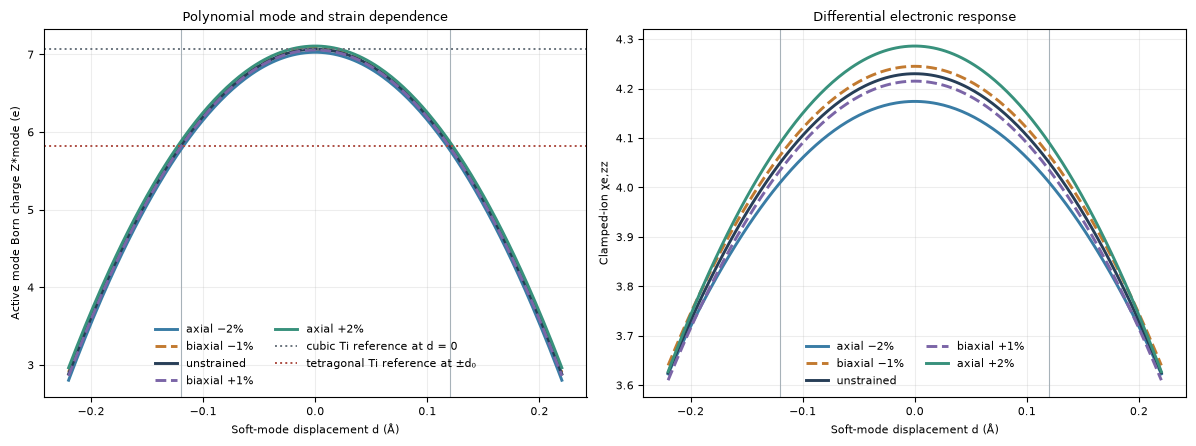

In [5]:
d_grid = np.linspace(-0.22, 0.22, 241)
strain_cases = [
    ("axial −2%", np.array([0.0, 0.0, -0.02]), "#397ca5", "-"),
    ("biaxial −1%", np.array([-0.01, -0.01, 0.0]), "#c27a30", "--"),
    ("unstrained", np.zeros(3), "#273e57", "-"),
    ("biaxial +1%", np.array([0.01, 0.01, 0.0]), "#7b65a7", "--"),
    ("axial +2%", np.array([0.0, 0.0, 0.02]), "#38917c", "-"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, strain, colour, style in strain_cases:
    z_mode = [bto_mode_charge(d, strain) for d in d_grid]
    chi_mode = [bto_electronic_susceptibility(d, strain)[2, 2] for d in d_grid]
    axes[0].plot(d_grid, z_mode, color=colour, ls=style, lw=2.1, label=label)
    axes[1].plot(d_grid, chi_mode, color=colour, ls=style, lw=2.1, label=label)
axes[0].axhline(bto_cubic_mode_charge_z, color="#6a747d", ls=":", lw=1.4,
                label="cubic Ti reference at d = 0")
axes[0].axhline(bto_mode_charge_z, color="#ad4e43", ls=":", lw=1.4,
                label="tetragonal Ti reference at ±d₀")
for ax in axes:
    for d_mark in (-bto_mode_d0, bto_mode_d0):
        ax.axvline(d_mark, color="#a7b2b9", lw=0.8, zorder=0)
    ax.set_xlabel("Soft-mode displacement d (Å)")
    ax.grid(alpha=0.22)
axes[0].set_ylabel("Active mode Born charge Z*mode (e)")
axes[0].set_title("Polynomial mode and strain dependence")
axes[0].legend(frameon=False, fontsize=8, ncol=2)
axes[1].set_ylabel("Clamped-ion χe,zz")
axes[1].set_title("Differential electronic response")
axes[1].legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


#### Strain derivatives

The plot compares fixed-mode and mode-relaxed piezoelectric response.

<details>
<summary><b>Background theory: polarization under strain</b></summary>

At zero field and fixed mode coordinate, the clamped piezoelectric response is

$$
e^{\mathrm{clamped}}_{zj}=\left.\frac{\partial P_z}{\partial\eta_j}\right|_d
 =\frac{1}{\Omega}\frac{\partial\mathcal D_z}{\partial\eta_j}
 -\frac{P_z}{1+\eta_j},
$$

where the last term comes from the changing cell volume. The strain derivative of the polynomial dipole is $\partial_{\eta_{zz}}\mathcal D_z=(g_z+h_zq^2/3)d$ and $\partial_{\eta_{xx}}\mathcal D_z=\partial_{\eta_{yy}}\mathcal D_z=(g_\perp+h_\perp q^2/3)d$. If the mode is also allowed to relax at fixed field, then

$$
\frac{\partial d_{\mathrm{eq}}}{\partial\eta_{zz}}
 =-\frac{\partial_{d\eta_{zz}}\mathcal H}{\partial_d^2\mathcal H},
\qquad
e^{\mathrm{relaxed}}_{zz}=e^{\mathrm{clamped}}_{zz}
 +\frac{Z^*_{\mathrm{mode}}}{\Omega}\frac{\partial d_{\mathrm{eq}}}{\partial\eta_{zz}}.
$$

The equations shown here and the next plot are evaluated at zero field, so $P_z=\mathcal D_z/\Omega$. At finite field, the clamped derivative also contains the explicit term $\epsilon_0 E_z\partial_{\eta_j}\chi_{e,zz}$; the changing-volume term acts on the ionic contribution $\mathcal D_z/\Omega$ only. The mode-relaxation contribution uses the full finite-field $\partial_dP_z$. The next cell follows both domain branches as the axial strain changes. The plotted continuum comes from the analytic function; the generated fitting set samples the endpoints and zero strain.

</details>

In [ ]:
eta_grid = np.linspace(-0.02, 0.02, 61)
strain_results = {"minus": [], "plus": []}
for eta_z in eta_grid:
    strain = np.array([0.0, 0.0, eta_z])
    volume_eta = bto_reference_volume * (1.0 + eta_z)
    minima = bto_stationary_displacements(0.0, strain, volume_eta)
    if len(minima) != 2:
        raise RuntimeError(f"Expected two stable domains at eta_zz={eta_z:+.4f}: {minima}")
    for domain, d_eq in zip(("minus", "plus"), minima):
        z_mode = bto_mode_charge(d_eq, strain)
        chi_clamped = bto_electronic_susceptibility(d_eq, strain)[2, 2]
        chi_relaxed = bto_relaxed_susceptibility(d_eq, strain, volume_eta)
        e_clamped = bto_clamped_piezoelectric(d_eq, strain, volume_eta, axis=2)
        e_relaxed = bto_relaxed_piezoelectric(
            d_eq, strain, volume_eta, axis=2
        )
        strain_results[domain].append({
            "d": d_eq,
            "Pz": bto_mode_dipole(d_eq, strain) / volume_eta,
            "Z": z_mode,
            "chi_clamped": chi_clamped,
            "chi_relaxed": chi_relaxed,
            "e_clamped": e_clamped * 16.02176634,
            "e_relaxed": e_relaxed * 16.02176634,
        })

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))
for domain, label, colour in (("minus", "negative domain", "#397ca5"),
                              ("plus", "positive domain", "#bf584a")):
    values = strain_results[domain]
    axes[0, 0].plot(eta_grid * 100, [v["Pz"] * 1602.176634 for v in values],
                    color=colour, lw=2.2, label=label)
    axes[0, 1].plot(eta_grid * 100, [v["Z"] for v in values],
                    color=colour, lw=2.2, label=label)
    axes[1, 1].plot(eta_grid * 100, [v["e_clamped"] for v in values],
                    color=colour, lw=1.8, ls="--", label=f"{label}, clamped")
    axes[1, 1].plot(eta_grid * 100, [v["e_relaxed"] for v in values],
                    color=colour, lw=2.2, label=f"{label}, relaxed")
positive = strain_results["plus"]
axes[1, 0].plot(eta_grid * 100, [v["chi_clamped"] for v in positive],
                color="#457f68", lw=2.2, label="clamped-ion χe")
axes[1, 0].plot(eta_grid * 100, [v["chi_relaxed"] for v in positive],
                color="#855da1", lw=2.2, label="mode-relaxed χ")
axes[0, 0].set(ylabel="Pz (µC cm⁻²)", title="Domain polarization")
axes[0, 1].set(ylabel="Z*mode (e)", title="Born charge at relaxed minimum")
axes[1, 0].set(ylabel="Longitudinal susceptibility", title="Clamped and relaxed response")
axes[1, 1].set(ylabel="e33 (C m⁻²)", title="Piezoelectric response")
for ax in axes.ravel():
    ax.set_xlabel("Axial strain ηzz (%)")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Analytic strain response: the two domains reverse P and e33", y=1.01)
fig.tight_layout()
plt.show()

for sign, d in (("−", -bto_mode_d0), ("+", bto_mode_d0)):
    strain = np.zeros(3)
    print(
        f"{sign} domain at zero strain: d={d:+.3f} Å, "
        f"Z*mode={bto_mode_charge(d, strain):.3f} e, "
        f"χclamped={bto_electronic_susceptibility(d, strain)[2, 2]:.3f}, "
        f"χrelaxed={bto_relaxed_susceptibility(d, strain, bto_reference_volume):.3f}"
    )


In [ ]:
field_train = read(asset_root / "data/macefield_batio3_toy_train.extxyz", index=":")
field_valid = read(asset_root / "data/macefield_batio3_toy_valid.extxyz", index=":")
print("train / validation frames:", len(field_train), "/", len(field_valid))
print("z fields (V/Å):", min(a.info["REF_electric_field"][2] for a in field_train),
      "to", max(a.info["REF_electric_field"][2] for a in field_train))
print("sampled axial strains:", sorted({round(float(a.info["REF_strain"][2]), 4) for a in field_train}))
print("sampled biaxial strains:", sorted({round(float(a.info["REF_strain"][0]), 4) for a in field_train}))
print("available labels:", sorted(field_train[0].info), sorted(field_train[0].arrays))
print("source:", field_train[0].info["label_source"])
print("Published reference Ti Z*zz: cubic =", bto_cubic_mode_charge_z,
      "e; tetragonal =", bto_mode_charge_z, "e")
print("Tetragonal reference BEC tensor for atom order Ba, Ti, O3, O2, O1:")
for symbol, tensor in zip(("Ba", "Ti", "O3", "O2", "O1"), bto_tetragonal_becs):
    print(f"{symbol}:\n{tensor}")
print("Tetragonal reference BEC acoustic-sum-rule residual:",
      np.linalg.norm(bto_tetragonal_becs.sum(axis=0)))
print("Unstrained Ti Z*zz at d=0, ±d0:",
      bto_mode_charge(0.0), bto_mode_charge(bto_mode_d0), bto_mode_charge(-bto_mode_d0))
print("Reference electronic susceptibility chi_e = epsilon_infinity - I:")
print(bto_electronic_susceptibility_tensor)


### 1.5 Train one model on all labels

The primary run jointly fits energy, forces, polarization, Born charges and clamped-ion susceptibility from random initialization. All targets come from one analytic enthalpy; polarizability uses the standardized symmetric Huber loss.

Edit the small run settings in `training_config` and run the next cell. For a quick demonstration, reduce `max_num_epochs`; change `device` in the setup cell to choose CPU or CUDA.


In [ ]:
source_revision = require_clean_source(source_root)
print("MACE-Field source revision:", source_revision)

run_dir = asset_root / "models" / "macefield_joint"
training_config = {
    "name": "MACEField-Landau",
    "model": "MACEField",
    "loss": "universal_field",
    "hidden_irreps": "16x0e + 16x1o",
    "num_interactions": 2,
    "r_max": 5.0,
    "train_file": str(asset_root / "data/macefield_batio3_toy_train.extxyz"),
    "valid_file": str(asset_root / "data/macefield_batio3_toy_valid.extxyz"),
    "valid_fraction": 0,
    "energy_key": "REF_energy",
    "forces_key": "REF_forces",
    "electric_field_key": "REF_electric_field",
    "polarization_key": "REF_polarization",
    "becs_key": "REF_becs",
    "polarizability_key": "REF_polarizability",
    "compute_forces": True,
    "compute_stress": False,
    "compute_polarization": True,
    "compute_becs": True,
    "compute_polarizability": True,
    "energy_weight": 1.0,
    "forces_weight": 100.0,
    "polarization_weight": 0.01,
    "becs_weight": 0.01,
    "polarizability_weight": 0.01,
    "stress_weight": 0.0,
    "polarizability_loss_mode": "standardized_symmetric_huber",
    "huber_delta": 0.5,
    "E0s": {8: 0.0, 22: 0.0, 56: 0.0},
    "batch_size": 32,
    "valid_batch_size": 32,
    "max_num_epochs": 120,
    "eval_interval": 10,
    "default_dtype": dtype,
    "device": device,
    "seed": 23,
    "lr": 0.005,
    "freeze": 0,
    "model_dir": str(run_dir),
}
train_mace(training_config)

field_model_path = run_dir / "MACEField-Landau_run-23.model"
run_python_script(
    asset_root / "scripts/calibrate_macefield_energy_offset.py",
    "--model", field_model_path,
    "--train-file", asset_root / "data/macefield_batio3_toy_train.extxyz",
    python_path=(tutorial_root, source_root),
)

audit_dir = run_dir / "surface-audit"
run_python_script(
    asset_root / "scripts/audit_macefield_surface.py",
    "--model", field_model_path,
    "--head", field_head,
    "--device", device,
    "--dtype", dtype,
    "--max-force-rmse-mev", "30.0",
    "--out", audit_dir,
    python_path=(tutorial_root, source_root),
)

setup_paths["macefield_model"] = field_model_path
setup_paths["macefield_model_kind"] = "jointly trained nonlinear toy model"
field_model_label = f"jointly trained nonlinear MACEField toy model · {device}"
print("Model:", field_model_path)
print("Surface audit:", audit_dir / "macefield-audit.json")


### 1.6 Build the primitive cell

Keep the model probe identical to the five-atom training motif. The displacement
argument below is in Å, not fractional coordinates. A larger repeat is useful
for viewing the motif, while response calculations use the primitive cell so
volume normalization is direct.

In [ ]:
bto_a, bto_c = 3.90, 4.10  # unstrained reference cell
toy_zstar = bto_mode_charge_z  # active-mode charge at either FE minimum, zero strain
toy_chi_e = bto_electronic_susceptibility_tensor.copy()
toy_alpha = eps0_e_per_v_angstrom * toy_chi_e  # e / (V Å)
field_response_info_keys = {
    "polarization": "REF_polarization",
    "polarizability": "REF_polarizability",
}
field_response_arrays_keys = {"becs": "REF_becs"}


def bto_probe(repeat=(1, 1, 1), a=bto_a, c=bto_c, ti_displacement=0.10,
              strain=(0.0, 0.0, 0.0), field=(0.0, 0.0, 0.0)):
    """Construct a strained five-atom probe and its analytic response masks."""
    scaled = [
        [0.0, 0.0, 0.0],       # Ba
        [0.5, 0.5, 0.5],       # Ti, displaced along z below
        [0.5, 0.5, 0.0],       # O3, axial oxygen
        [0.5, 0.0, 0.5],       # O2, y-bridge oxygen
        [0.0, 0.5, 0.5],       # O1, x-bridge oxygen
    ]
    eta = np.asarray(strain, dtype=float)
    cell = np.diag(np.array([a, a, c]) * (1.0 + eta))
    atoms = Atoms("BaTiO3", scaled_positions=scaled, cell=cell, pbc=True)
    reference_positions = atoms.positions.copy()
    atoms.positions[1, 2] += ti_displacement
    labels = evaluate_bto_toy_state(
        displacement=ti_displacement, strain=eta, field=np.asarray(field, dtype=float),
        atomic_displacements=atoms.positions - reference_positions,
        volume=atoms.get_volume(),
    )
    atoms.info["REF_energy"] = labels["energy"]
    atoms.info["REF_electric_field"] = np.asarray(field, dtype=float)
    atoms.info["REF_polarization"] = labels["polarization"]
    atoms.info["REF_polarizability"] = labels["polarizability"].reshape(-1)
    atoms.info["REF_strain"] = eta
    atoms.info["REF_mode_displacement"] = float(ti_displacement)
    atoms.new_array("REF_forces", labels["forces"])
    atoms.new_array("REF_becs", labels["becs"].reshape(len(atoms), 9))
    return atoms.repeat(repeat)


bto = bto_probe(repeat=(2, 2, 2))
print(bto.get_chemical_formula(), "atoms:", len(bto), "cell volume (Å³):", bto.get_volume())
display(show_structure(bto, title="BaTiO₃-like ferroelectric motif, 2×2×2"))


### 1.7 Check the field derivative against energy differences

At fixed positive soft-mode displacement, scan the trained model over the
field range covered by the toy data. The finite-difference slope is an
independent check of the sign and volume normalization in the calculator.

In [ ]:
field_calc_path = Path(setup_paths["macefield_model"])
field_scan_limit = 0.16
field_scan_points = 17
field_values = np.linspace(-field_scan_limit, field_scan_limit, field_scan_points)
field_energies, field_polarizations = [], []
for ez in field_values:
    atoms = bto_probe()
    atoms.calc = MACECalculator(
        model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
        device=device, default_dtype=dtype,
        electric_field=[0.0, 0.0, float(ez)],
        compute_polarization=True, compute_becs=False, compute_polarizability=False,
    )
    field_energies.append(atoms.get_potential_energy())
    field_polarizations.append(np.asarray(atoms.calc.results["polarization"]))
field_energies = np.asarray(field_energies)
field_polarizations = np.asarray(field_polarizations)

volume = bto_probe().get_volume()
p_fd_z = -np.gradient(field_energies, field_values) / volume
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(field_values, field_energies - field_energies.min(), "o-", color="#315a7d")
axes[0].set(xlabel="Applied field Ez (V/Å)", ylabel="Relative energy (eV)")
axes[1].plot(field_values, field_polarizations[:, 2], "o-", label="Autograd Pz")
axes[1].plot(field_values, p_fd_z, "s--", label="− finite-difference dE/dEz / Ω")
axes[1].set(xlabel="Applied field Ez (V/Å)", ylabel="Pz (e Å⁻²)")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle("MACEField response at fixed Ti displacement")
fig.tight_layout()
plt.show()
print("max |Pz − finite-difference Pz| (e Å⁻²):",
      float(np.max(np.abs(field_polarizations[:, 2] - p_fd_z))))

### 1.8 Reference switching: follow metastable minima

Hysteresis is path dependence. Minimizing independently at every field selects the lowest-energy state and hides metastable branches. A quasi-static sweep instead carries a local minimum forward until it loses stability.

First build the analytic nonlinear Landau reference loop. Then follow the trained model’s field-dependent local minima. The reference polarization includes both the mode-dependent dipole and the clamped-ion dielectric term.

<details>
<summary><b>Background theory: nonlinear spinodal</b></summary>

The local branch ends where both derivatives vanish:

$$
\partial_d\mathcal H=U'_0(d)-E_z Z^*_{\mathrm{mode}}(d)
-\frac{\Omega\epsilon_0}{2}E_z^2\,\partial_d\chi_{e,zz}(d)=0,
$$
$$
\partial_d^2\mathcal H=U''_0(d)-E_z\partial_d Z^*_{\mathrm{mode}}(d)
-\frac{\Omega\epsilon_0}{2}E_z^2\,\partial_d^2\chi_{e,zz}(d)=0.
$$

Solve this pair for $(d,E_z)$ on each branch. With the tutorial coefficients, the zero-strain spinodals are approximately **−0.0482 and +0.0482 V/Å**. The shift from a constant-charge Landau model comes from the changing mode charge and the state-dependent dielectric term.
</details>


In [ ]:
# Follow local minima of the same nonlinear enthalpy used to generate the data.
volume_ref = bto_reference_volume
field_up = np.linspace(-0.16, 0.16, 81)
field_cycle = np.concatenate([field_up, field_up[-2::-1]])
n_up = len(field_up)
zero_strain = np.zeros(3)

def stable_displacements(ez):
    return bto_stationary_displacements(float(ez), zero_strain, volume_ref)

def local_minimum_branch(fields):
    previous = -bto_mode_d0
    branch = []
    for ez in fields:
        minima = stable_displacements(ez)
        if not minima:
            raise RuntimeError(f"No stable minimum found at Ez={ez:g} V/Å")
        previous = min(minima, key=lambda candidate: abs(candidate - previous))
        branch.append(previous)
    return np.asarray(branch)

def global_minimum_branch(fields):
    branch = []
    for ez in fields:
        minima = stable_displacements(ez)
        branch.append(min(minima, key=lambda d: bto_enthalpy(
            d, zero_strain, np.array([0.0, 0.0, ez]), volume_ref
        )))
    return np.asarray(branch)

def reference_polarization(d_values, fields):
    return np.asarray([
        bto_mode_dipole(d, zero_strain) / volume_ref
        + eps0_e_per_v_angstrom
        * bto_electronic_susceptibility(d, zero_strain)[2, 2] * ez
        for d, ez in zip(d_values, fields)
    ])

reference_d = local_minimum_branch(field_cycle)
reference_pz = reference_polarization(reference_d, field_cycle)
equilibrium_d = global_minimum_branch(field_cycle)
equilibrium_pz = reference_polarization(equilibrium_d, field_cycle)
jump_up = int(np.argmax(np.abs(np.diff(reference_d[:n_up]))) + 1)
jump_down = int(np.argmax(np.abs(np.diff(reference_d[n_up - 1:]))) + n_up)
from scipy.optimize import root
spinodal_up = root(
    lambda x: bto_field_stationary_derivatives(x[0], zero_strain, x[1], volume_ref),
    x0=[-bto_mode_d0 / np.sqrt(3.0), 0.05],
).x
spinodal_down = root(
    lambda x: bto_field_stationary_derivatives(x[0], zero_strain, x[1], volume_ref),
    x0=[bto_mode_d0 / np.sqrt(3.0), -0.05],
).x
print(f"Quasi-static up-sweep jump: Ez ≈ {field_cycle[jump_up]:+.3f} V/Å")
print(f"Quasi-static down-sweep jump: Ez ≈ {field_cycle[jump_down]:+.3f} V/Å")
print("Analytic spinodals (V/Å):", round(float(spinodal_down[1]), 5),
      round(float(spinodal_up[1]), 5))


In [ ]:
up_color, down_color, eq_color = "#b5483a", "#276b91", "#555b66"
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))

# A true history-dependent P(E) loop from the analytic reference.
axes[0].plot(field_cycle[:n_up], reference_pz[:n_up] * 1602.176634,
             color=up_color, lw=2.5, label="Increasing field")
axes[0].plot(field_cycle[n_up - 1:], reference_pz[n_up - 1:] * 1602.176634,
             color=down_color, lw=2.5, label="Decreasing field")
axes[0].plot(field_cycle, equilibrium_pz * 1602.176634, "--",
             color=eq_color, lw=1.4, label="Lowest-energy state at each field")
axes[0].scatter(field_cycle[[jump_up, jump_down]],
                reference_pz[[jump_up, jump_down]] * 1602.176634,
                marker="*", s=115, color="#e0a126", edgecolor="black",
                linewidth=0.5, zorder=5, label="Loss of metastability")
axes[0].set(xlabel="Applied field $E_z$ (V/Å)",
            ylabel="Polarization $P_z$ (µC cm$^{-2}$)",
            title="Polarization hysteresis")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(field_cycle[:n_up], reference_d[:n_up],
             color=up_color, lw=2.5, label="Increasing field")
axes[1].plot(field_cycle[n_up - 1:], reference_d[n_up - 1:],
             color=down_color, lw=2.5, label="Decreasing field")
axes[1].plot(field_cycle, equilibrium_d, "--",
             color=eq_color, lw=1.4, label="Lowest-energy state")
axes[1].scatter(field_cycle[[jump_up, jump_down]],
                reference_d[[jump_up, jump_down]], marker="*", s=115,
                color="#e0a126", edgecolor="black", linewidth=0.5, zorder=5)
axes[1].set(xlabel="Applied field $E_z$ (V/Å)",
            ylabel="Soft-mode displacement $d$ (Å)",
            title="History-dependent structural coordinate")
for ax in axes:
    ax.grid(alpha=0.22)
    ax.axhline(0.0, color="#555555", lw=0.7)
fig.suptitle("Analytic Landau reference · zero-temperature constrained switching", y=1.02)
fig.tight_layout()
plt.show()


The colored branches retain memory of the sweep direction. The dashed equilibrium curve switches at the global energy crossing and has no metastable loop. The stars mark where a followed local minimum disappears. This is a teaching reference generated directly from the labelled energy surface, not a claim about experimental BaTiO₃ coercivity, domains or thermal switching.


#### Response along the switching branches

At finite field, the active mode charge includes both the ionic dipole derivative and the field-induced electronic response. The next figure compares this BEC with clamped-ion and mode-relaxed susceptibility; the relaxed response grows near loss of stability.

In [ ]:
response_field_up = np.linspace(-0.16, 0.16, 161)
response_rows = {}
for direction, fields, initial_d in (
    ("up", response_field_up, -bto_mode_d0),
    ("down", response_field_up[::-1], bto_mode_d0),
):
    previous = initial_d
    rows = []
    for ez in fields:
        minima = bto_stationary_displacements(
            float(ez), zero_strain, volume_ref
        )
        if not minima:
            continue
        d_eq = min(minima, key=lambda candidate: abs(candidate - previous))
        previous = d_eq
        chi_clamped = bto_electronic_susceptibility(d_eq, zero_strain)[2, 2]
        rows.append({
            "E": float(ez),
            "d": d_eq,
            "P": bto_mode_dipole(d_eq, zero_strain) / volume_ref
                 + eps0_e_per_v_angstrom * chi_clamped * float(ez),
            "Z": bto_field_mode_charge(d_eq, zero_strain, float(ez), volume_ref),
            "chi_clamped": chi_clamped,
            "chi_relaxed": bto_relaxed_susceptibility(
                d_eq, zero_strain, volume_ref, field_z=float(ez)
            ),
        })
    response_rows[direction] = rows

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for direction, label, colour in (("up", "Increasing field", "#b5483a"),
                                 ("down", "Decreasing field", "#276b91")):
    rows = response_rows[direction]
    e = [row["E"] for row in rows]
    axes[0].plot(e, [row["P"] * 1602.176634 for row in rows],
                 color=colour, lw=2.2, label=label)
    axes[1].plot(e, [row["Z"] for row in rows],
                 color=colour, lw=2.2, label=label)
    axes[2].plot(e, [row["chi_clamped"] for row in rows],
                 color=colour, ls="--", lw=1.8, label=f"{label}: clamped")
    axes[2].plot(e, [row["chi_relaxed"] for row in rows],
                 color=colour, lw=2.2, label=f"{label}: mode-relaxed")
axes[0].set(xlabel="Applied field Ez (V/Å)", ylabel="Pz (µC cm⁻²)",
            title="Polarization history")
axes[1].set(xlabel="Applied field Ez (V/Å)", ylabel="Finite-field mode Z* (e)",
            title="BEC includes dχe/dd at finite field")
axes[2].set(xlabel="Applied field Ez (V/Å)", ylabel="Longitudinal susceptibility",
            title="Clamped and relaxed derivatives")
axes[2].set_yscale("log")
for ax in axes:
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=7)
fig.suptitle("Analytic response derivatives along both metastable branches", y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
d_probe = np.linspace(-0.14, 0.14, 29)
model_energy, model_force = [], []
well_calc = MACECalculator(
    model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, 0.0],
    compute_polarization=False, compute_becs=False, compute_polarizability=False,
)
for displacement in d_probe:
    atoms = bto_probe(ti_displacement=float(displacement))
    atoms.calc = well_calc
    model_energy.append(atoms.get_potential_energy())
    model_force.append(atoms.get_forces()[1, 2])
model_energy = np.asarray(model_energy)
model_force = np.asarray(model_force)
local_minima = np.where((model_energy[1:-1] < model_energy[:-2]) &
                        (model_energy[1:-1] < model_energy[2:]))[0] + 1
if len(local_minima) < 2:
    raise RuntimeError("The scan did not resolve two zero-field minima.")
barrier = model_energy[np.argmin(np.abs(d_probe))] - model_energy[local_minima].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(d_probe, model_energy - model_energy.min(), "o-",
             color="#276b91", label=field_model_label)
target_energy = 0.025 * ((d_probe**2 / 0.12**2) - 1.0) ** 2
target_force = -4.0 * 0.025 * d_probe * (d_probe**2 - 0.12**2) / 0.12**4
axes[0].plot(d_probe, target_energy, "--", color="#b5483a", lw=1.8,
             label="Analytic training target")
axes[1].plot(d_probe, target_force, "--", color="#b5483a", lw=1.8,
             label="Analytic training target")
axes[0].scatter(d_probe[local_minima], (model_energy - model_energy.min())[local_minima],
                color="#e0a126", edgecolor="black", zorder=4, label="Local minima")
axes[0].set(xlabel="Ti displacement d (Å)", ylabel="Relative energy (eV/cell)",
            title=f"Selected model: zero-field double well")
axes[0].legend(frameon=False)
axes[1].plot(d_probe, model_force, "o-", color="#276b91", ms=3)
axes[1].axhline(0.0, color="#555555", lw=0.7)
axes[1].set(xlabel="Ti displacement d (Å)", ylabel="Force on Ti z (eV/Å)",
            title="Energy derivative along the soft mode")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.22)
fig.tight_layout()
plt.show()
print(f"{field_model_label} minima (Å):", np.round(d_probe[local_minima], 3))
print(f"Center-to-well barrier (meV/cell): {barrier * 1000:.3f}")


### 1.8a Switching predicted by the trained MACEField model

The scratch-trained toy checkpoint is evaluated with the same MACE-Field implementation used for training. Carry each relaxed structure into the next field step; only the Ti z coordinate is free. The trained toy model and analytic reference use the same ±0.16 V/Å sweep, which spans both metastable branches and the predicted spinodal near ±0.048 V/Å. Both follow the same constrained five-atom path.

A physical interpretation requires model and cell convergence. The switching field here is a result for this checkpoint and constrained path; it is not an experimental coercive field.


In [ ]:
from ase.constraints import FixAtoms
from ase.optimize import BFGS

model_field_limit = 0.16
model_field_steps = 81
model_fields_up = np.linspace(-model_field_limit, model_field_limit, model_field_steps)
model_field_cycle = np.concatenate([model_fields_up, model_fields_up[-2::-1]])
model_branch_d, model_branch_pz, model_states = [], [], []
relaxed = bto_probe(ti_displacement=-0.10)
relaxed.set_constraint(FixAtoms(indices=[0, 2, 3, 4]))
field_loop_calc = MACECalculator(
    model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, float(model_field_cycle[0])],
    compute_forces=True, compute_polarization=True,
    compute_becs=False, compute_polarizability=False,
)
relaxed.calc = field_loop_calc

for ez in model_field_cycle:
    field_loop_calc.electric_field = [0.0, 0.0, float(ez)]
    field_loop_calc.reset()
    optimizer = BFGS(relaxed, logfile=None)
    converged = optimizer.run(fmax=3.0e-4, steps=60)
    if not converged:
        raise RuntimeError(f"Model field relaxation did not converge at Ez={ez:+.4f} V/Å")
    model_branch_d.append(float(relaxed.positions[1, 2] - bto_c / 2))
    model_branch_pz.append(float(relaxed.calc.results["polarization"][2]))
    model_states.append(relaxed.copy())

model_branch_d = np.asarray(model_branch_d)
model_branch_pz = np.asarray(model_branch_pz)
n_up = len(model_fields_up)
model_up_jump = int(np.argmax(np.abs(np.diff(model_branch_d[:n_up]))) + 1)
model_down_jump = int(np.argmax(np.abs(np.diff(model_branch_d[n_up - 1:]))) + n_up)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(field_cycle[:n_up], reference_pz[:n_up] * 1602.176634,
             color="#9b3d34", lw=1.8, ls="--", label="Analytic · increasing")
axes[0].plot(field_cycle[n_up - 1:], reference_pz[n_up - 1:] * 1602.176634,
             color="#244e6b", lw=1.8, ls="--", label="Analytic · decreasing")
axes[0].plot(model_field_cycle[:n_up], model_branch_pz[:n_up] * 1602.176634,
             color="#b5483a", lw=2.6, label="MACEField · increasing")
axes[0].plot(model_field_cycle[n_up - 1:], model_branch_pz[n_up - 1:] * 1602.176634,
             color="#276b91", lw=2.6, label="MACEField · decreasing")
axes[0].scatter(model_field_cycle[[model_up_jump, model_down_jump]],
                model_branch_pz[[model_up_jump, model_down_jump]] * 1602.176634,
                marker="*", s=110, color="#e0a126", edgecolor="black",
                linewidth=0.5, zorder=5, label="Switching step")
axes[0].set(xlabel="Applied field Ez (V/Å)", ylabel="Polarization Pz (µC cm⁻²)",
            title="Trained-model and analytic polarization loops")
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(field_cycle[:n_up], reference_d[:n_up],
             color="#9b3d34", lw=1.8, ls="--", label="Analytic · increasing")
axes[1].plot(field_cycle[n_up - 1:], reference_d[n_up - 1:],
             color="#244e6b", lw=1.8, ls="--", label="Analytic · decreasing")
axes[1].plot(model_field_cycle[:n_up], model_branch_d[:n_up],
             color="#b5483a", lw=2.6, label="MACEField · increasing")
axes[1].plot(model_field_cycle[n_up - 1:], model_branch_d[n_up - 1:],
             color="#276b91", lw=2.6, label="MACEField · decreasing")
axes[1].scatter(model_field_cycle[[model_up_jump, model_down_jump]],
                model_branch_d[[model_up_jump, model_down_jump]], marker="*", s=110,
                color="#e0a126", edgecolor="black", linewidth=0.5, zorder=5)
axes[1].set(xlabel="Applied field Ez (V/Å)", ylabel="Ti displacement d (Å)",
            title="Trained-model and analytic structural branches")
for ax in axes:
    ax.grid(alpha=0.22)
    ax.axhline(0.0, color="#555555", lw=0.7)
fig.tight_layout()
plt.show()
zero_up = int(np.argmin(np.abs(model_field_cycle[:n_up])))
zero_down = n_up - 1 + int(np.argmin(np.abs(model_field_cycle[n_up - 1:])))
print("Analytic spinodals: "
      f"{spinodal_down[1]:+.4f}, {spinodal_up[1]:+.4f} V/Å")
print(f"MACEField switching fields: {model_field_cycle[model_up_jump]:+.4f}, {model_field_cycle[model_down_jump]:+.4f} V/Å")
print(f"Analytic branch jumps: {field_cycle[jump_up]:+.4f}, {field_cycle[jump_down]:+.4f} V/Å")
print(f"Model remanent Pz: {model_branch_pz[zero_up]:+.5f}, {model_branch_pz[zero_down]:+.5f} e/Å²")
loop_rmse = np.sqrt(np.mean((model_branch_pz - reference_pz) ** 2)) * 1602.176634
print(f"Full-cycle polarization RMSE vs analytic reference: {loop_rmse:.3f} µC/cm²")
print("All relaxation steps converged:", len(model_states), "of", len(model_field_cycle))


#### Animate the model-predicted switching path

The slider follows the relaxed sequence used in the loop. The view repeats the cell for clarity; polarization values are those of the primitive cell.

In [ ]:
frame_indices = list(range(0, len(model_states), 2))
if frame_indices[-1] != len(model_states) - 1:
    frame_indices.append(len(model_states) - 1)
visual_states = [model_states[i].repeat((2, 2, 2)) for i in frame_indices]
visual_vectors = [
    [{
        "origin": state.get_center_of_mass(),
        "vector": [0.0, 0.0, model_branch_pz[i]],
        "label": "P",
        "units": "e Å⁻²",
        "color": "#13849a",
        "length": 1.6,
    }]
    for i, state in zip(frame_indices, visual_states)
]
frame_labels = [
    f"{model_field_cycle[i]:+.3f} V/Å · {model_branch_pz[i] * 1602.176634:+.1f} µC/cm²"
    for i in frame_indices
]
display(animate_structures(
    visual_states,
    title=f"BaTiO₃-like switching path · {field_model_label}",
    frame_labels=frame_labels,
    vectors_by_frame=visual_vectors,
    show_cell=True,
))

### 1.9 Born effective charges and electric susceptibility

The model's active Ti $Z^*_{zz}$ changes with the soft-mode displacement and diagonal strain. At finite field, it also contains the derivative of the state-dependent clamped-ion susceptibility with respect to position. The Ti/Ba correction is equal and opposite, preserving the acoustic sum rule. The remaining tensor entries retain the tetragonal reference values.

MACEField's `polarizability` output is the clamped-ion dimensionless tensor $\chi_e=(1/\epsilon_0)\partial P/\partial E|_{R,\eta}$. Letting the mode relax adds a separate ionic term controlled by the curvature of its local minimum; close to a spinodal the relaxed differential susceptibility becomes large. The analytic plot above separates these two quantities. Display signed BEC entries because taking absolute values would hide their cancellations.


In [ ]:
response_atoms = bto_probe(ti_displacement=0.09)
response_atoms.calc = MACECalculator(
    model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, 0.0],
    compute_polarization=True, compute_becs=True, compute_polarizability=True,
    info_keys=field_response_info_keys,
    arrays_keys=field_response_arrays_keys,
)
response_atoms.get_potential_energy()
becs = np.asarray(response_atoms.calc.results["becs"]).reshape(len(response_atoms), 3, 3)
chi_e = np.asarray(response_atoms.calc.results["polarizability"]).reshape(3, 3)
species = response_atoms.get_chemical_symbols()
component_labels = [f"{a}{b}" for a in "xyz" for b in "xyz"]
site_labels = ["Ba", "Ti", "O3 (axial)", "O2 (y bridge)", "O1 (x bridge)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
bec_matrix = becs.reshape(len(response_atoms), 9)
bec_limit = float(np.max(np.abs(bec_matrix)))
bec_image = axes[0].imshow(bec_matrix, cmap="RdBu_r", vmin=-bec_limit, vmax=bec_limit,
                           aspect="auto")
axes[0].set(xticks=np.arange(9), xticklabels=component_labels,
            yticks=np.arange(len(site_labels)), yticklabels=site_labels,
            xlabel="Polarization alpha · displacement beta",
            title="Born effective charge Z* (e)")
axes[0].tick_params(axis="x", labelrotation=45)
for row in range(bec_matrix.shape[0]):
    for col in range(bec_matrix.shape[1]):
        value = bec_matrix[row, col]
        colour = "white" if abs(value) > 0.55 * bec_limit else "#183346"
        axes[0].text(col, row, f"{value:.1f}", ha="center", va="center",
                     fontsize=7, color=colour)
fig.colorbar(bec_image, ax=axes[0], fraction=0.046, pad=0.04)

chi_image = axes[1].imshow(chi_e, cmap="YlGnBu", vmin=0.0,
                           vmax=max(float(np.max(np.abs(chi_e))), 1e-8))
axes[1].set(xticks=range(3), yticks=range(3), xticklabels=list("xyz"),
            yticklabels=list("xyz"), xlabel="Field beta", ylabel="Polarization alpha",
            title="Electric susceptibility chi_e")
for row in range(3):
    for col in range(3):
        axes[1].text(col, row, f"{chi_e[row, col]:.2f}",
                     ha="center", va="center", fontsize=10, color="#15364a")
fig.colorbar(chi_image, ax=axes[1], fraction=0.046, pad=0.04, label="dimensionless")

chi_symmetric = 0.5 * (chi_e + chi_e.T)
eigenvalues = np.linalg.eigvalsh(chi_symmetric)
axes[2].bar(np.arange(1, 4), eigenvalues, color=["#3d8c88", "#337c99", "#526b9a"])
axes[2].set(xticks=[1, 2, 3], xlabel="Principal direction",
            ylabel="Eigenvalue of symmetric chi_e", title="Susceptibility principal values")
for x, value in enumerate(eigenvalues, start=1):
    axes[2].text(x, value, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
axes[2].grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

asr = float(np.linalg.norm(becs.sum(axis=0)))
symmetry_residual = float(np.linalg.norm(chi_e - chi_e.T))
print(f"Born-charge acoustic sum-rule residual: {asr:.3e} e")
print(f"Susceptibility antisymmetric residual: {symmetry_residual:.3e}")
print("Principal susceptibility values:", np.round(eigenvalues, 4))


The figure below shows model predictions at a positive-domain structure and zero strain. The labels change across displacement and strain; the displayed spectrum is only one slice. Compare the response with the analytic surfaces above, check the acoustic sum rule, and repeat the probe at the other domain and strained cells.


In [ ]:
# Compare MACEField's higher derivatives with finite differences of its polarization.
# The second probe checks a strained domain at nonzero field, where chi_e(d) also shifts Z*.
delta_d = 1.0e-3
delta_field = 1.0e-3
finite_difference_cases = [
    (0.09, np.array([0.0, 0.0, 0.0]), 0.0),
    (bto_mode_d0, np.array([0.0, 0.0, 0.02]), 0.06),
]

def model_polarization(displacement, strain, ez):
    atoms = bto_probe(
        ti_displacement=float(displacement), strain=strain,
        field=(0.0, 0.0, float(ez)),
    )
    atoms.calc = MACECalculator(
        model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
        device=device, default_dtype=dtype,
        electric_field=[0.0, 0.0, float(ez)],
        compute_polarization=True, compute_becs=False, compute_polarizability=False,
    )
    atoms.get_potential_energy()
    return np.asarray(atoms.calc.results["polarization"]), atoms.get_volume()

for displacement, strain, ez in finite_difference_cases:
    atoms = bto_probe(
        ti_displacement=displacement, strain=strain, field=(0.0, 0.0, ez),
    )
    atoms.calc = MACECalculator(
        model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
        device=device, default_dtype=dtype,
        electric_field=[0.0, 0.0, ez],
        compute_polarization=True, compute_becs=True, compute_polarizability=True,
        info_keys=field_response_info_keys, arrays_keys=field_response_arrays_keys,
    )
    atoms.get_potential_energy()
    becs_now = np.asarray(atoms.calc.results["becs"]).reshape(len(atoms), 3, 3)
    chi_now = np.asarray(atoms.calc.results["polarizability"]).reshape(3, 3)
    p_minus, volume = model_polarization(displacement - delta_d, strain, ez)
    p_plus, _ = model_polarization(displacement + delta_d, strain, ez)
    bec_ti_fd = volume * (p_plus[2] - p_minus[2]) / (2.0 * delta_d)
    p_e_minus, _ = model_polarization(displacement, strain, ez - delta_field)
    p_e_plus, _ = model_polarization(displacement, strain, ez + delta_field)
    chi_zz_fd = (p_e_plus[2] - p_e_minus[2]) / (
        2.0 * delta_field * eps0_e_per_v_angstrom
    )
    print(
        f"d={displacement:+.3f} Å, eta_zz={strain[2]:+.3f}, Ez={ez:+.3f} V/Å: "
        f"Ti Z*zz autograd/FD = {becs_now[1, 2, 2]:.5f}/{bec_ti_fd:.5f}; "
        f"chi_e,zz autograd/FD = {chi_now[2, 2]:.5f}/{chi_zz_fd:.5f}"
    )


#### Inspect the structure and response together

The arrow uses a fixed display length so the small physical polarization remains visible; hover to read its value and units. Diverging atom colors show signed Z*zz values. Move the sliders to compare the two wells and the field-induced response.


In [ ]:
field_displacements = np.linspace(-0.14, 0.14, 15)
field_scan_states = []
field_scan_becs = []
field_scan_vectors = []
field_scan_labels = []
field_scan_calc = MACECalculator(
    model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, 0.0],
    compute_polarization=True, compute_becs=True, compute_polarizability=False,
    info_keys=field_response_info_keys,
    arrays_keys=field_response_arrays_keys,
)
for displacement in field_displacements:
    atoms = bto_probe(ti_displacement=float(displacement))
    atoms.calc = field_scan_calc
    atoms.get_potential_energy()
    polarization = np.asarray(atoms.calc.results["polarization"])
    bec_zz = np.asarray(atoms.calc.results["becs"]).reshape(len(atoms), 3, 3)[:, 2, 2]
    field_scan_states.append(atoms.copy())
    field_scan_becs.append(bec_zz)
    field_scan_vectors.append([{
        "origin": atoms.positions.mean(axis=0),
        "vector": polarization,
        "label": "Polarization",
        "units": "e Å⁻²",
        "color": "#147d9b",
        "length": 1.6,
    }])
    field_scan_labels.append(
        f"Ti displacement {displacement:+.3f} Å · Ez = 0 V/Å · "
        f"Pz = {polarization[2]:+.4f} e Å⁻²"
    )

display(animate_structures(
    field_scan_states,
    title=f"MACEField response along the soft mode · {field_model_label}",
    frame_labels=field_scan_labels,
    atom_values=field_scan_becs,
    scalar_name="Z*zz",
    scalar_units="e",
    vectors_by_frame=field_scan_vectors,
    show_cell=True,
    height=500,
    play_speed=320,
))


#### Probe the fitted response across strained cells

Compare the fitted model with the analytic labels at both domain minima. Then scrub the JavaScript structure viewer to see the axial cell change and read the Ti $Z^*_{zz}$ overlay.

In [ ]:
strain_values = np.array([-0.02, 0.0, 0.02])
strain_predictions = {"negative": [], "positive": []}
strain_view_states, strain_view_values, strain_view_vectors, strain_view_labels = [], [], [], []
strain_calc = MACECalculator(
    model_paths=str(field_calc_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, 0.0],
    compute_polarization=True, compute_becs=True, compute_polarizability=True,
    info_keys=field_response_info_keys,
    arrays_keys=field_response_arrays_keys,
)

for eta_z in strain_values:
    strain = np.array([0.0, 0.0, float(eta_z)])
    volume = bto_reference_volume * (1.0 + float(eta_z))
    minima = bto_stationary_displacements(0.0, strain, volume)
    if len(minima) != 2:
        raise RuntimeError(f"Expected two stable domains at eta_zz={eta_z:+.3f}: {minima}")
    for domain, displacement in zip(("negative", "positive"), minima):
        atoms = bto_probe(ti_displacement=float(displacement), strain=strain)
        atoms.calc = strain_calc
        atoms.get_potential_energy()
        model_p = np.asarray(strain_calc.results["polarization"], dtype=float)
        model_becs = np.asarray(strain_calc.results["becs"], dtype=float).reshape(len(atoms), 3, 3)
        model_chi = np.asarray(strain_calc.results["polarizability"], dtype=float).reshape(3, 3)
        label_p = np.asarray(atoms.info["REF_polarization"], dtype=float)
        label_becs = np.asarray(atoms.arrays["REF_becs"], dtype=float).reshape(len(atoms), 3, 3)
        label_chi = np.asarray(atoms.info["REF_polarizability"], dtype=float).reshape(3, 3)
        strain_predictions[domain].append({
            "eta": float(eta_z),
            "d": float(displacement),
            "model_P": float(model_p[2] * 1602.176634),
            "label_P": float(label_p[2] * 1602.176634),
            "model_Z": float(model_becs[1, 2, 2]),
            "label_Z": float(label_becs[1, 2, 2]),
            "model_chi": float(model_chi[2, 2]),
            "label_chi": float(label_chi[2, 2]),
        })
        strain_view_states.append(atoms.copy())
        strain_view_values.append(model_becs[:, 2, 2])
        strain_view_vectors.append([{
            "origin": atoms.positions.mean(axis=0),
            "vector": model_p,
            "label": "P",
            "units": "e Å⁻²",
            "color": "#147d9b",
            "length": 1.6,
        }])
        strain_view_labels.append(
            f"ηzz={eta_z:+.1%} · d={displacement:+.3f} Å · "
            f"Z*Ti,zz={model_becs[1, 2, 2]:.2f} e"
        )

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for domain, colour, name in (("negative", "#397ca5", "negative domain"),
                             ("positive", "#bf584a", "positive domain")):
    rows = strain_predictions[domain]
    eta_percent = np.array([row["eta"] * 100 for row in rows])
    for ax, key, ylabel, title in (
        (axes[0], "P", "Pz (µC cm⁻²)", "Polarization"),
        (axes[1], "Z", "Ti Z*zz (e)", "Mode Born charge"),
        (axes[2], "chi", "χe,zz", "Clamped-ion susceptibility"),
    ):
        ax.plot(eta_percent, [row[f"label_{key}"] for row in rows],
                color=colour, ls="--", lw=1.6, label=f"{name} · analytic")
        ax.scatter(eta_percent, [row[f"model_{key}"] for row in rows],
                   color=colour, s=42, edgecolor="white", linewidth=0.6,
                   zorder=3, label=f"{name} · MACEField")
        ax.set(xlabel="Axial strain ηzz (%)", ylabel=ylabel, title=title)
        ax.grid(alpha=0.22)
for ax in axes:
    ax.legend(frameon=False, fontsize=7)
fig.suptitle("Jointly fitted response at both strained domain minima")
fig.tight_layout()
plt.show()

for domain in ("negative", "positive"):
    for row in strain_predictions[domain]:
        print(
            f"{domain:8s} ηzz={row['eta']:+.1%} d={row['d']:+.4f} Å | "
            f"ΔP={row['model_P'] - row['label_P']:+.2f} µC/cm², "
            f"ΔZ*={row['model_Z'] - row['label_Z']:+.3f} e, "
            f"Δχ={row['model_chi'] - row['label_chi']:+.3f}"
        )

display(animate_structures(
    strain_view_states,
    title=f"MACEField response at both domains under axial strain · {field_model_label}",
    frame_labels=strain_view_labels,
    atom_values=strain_view_values,
    scalar_name="Z*zz",
    scalar_units="e",
    vectors_by_frame=strain_view_vectors,
    show_cell=True,
    height=500,
))


### 1.10 Training contract and model limits

The joint data cover the double well, fields around the spinodals and five strain states. The training config above fits all labels from scratch; the scripts `train_macefield.sh` and `train_macefield_response_finetune.sh` also show an energy/force baseline followed by response fine-tuning.

The toy's nonlinear coefficients are pedagogical; literature values anchor the cubic and tetragonal Ti $Z^*_{zz}$ and unstrained tetragonal $\epsilon_\infty$. This five-atom, one-mode model is not a DFT or experimental BaTiO₃ model. It omits domain walls, thermal fluctuations and a full phonon eigenvector. Clamped-ion and mode-relaxed susceptibilities are different observables.


In [ ]:
macefield_data_keys = {
    "model": "MACEField",
    "electric_field_key": "REF_electric_field",
    "polarization_key": "REF_polarization",
    "becs_key": "REF_becs",
    "polarizability_key": "REF_polarizability",
    "loss": "UniversalField",
}
macefield_data_keys

## Continue

Compare this design in [T00 — Extending MACE](T00-Extending-MACE.ipynb). For training, see [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) and [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb); for architecture, see [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb). Source revisions, example-data limits and acknowledgements are in the [extension guide](README.md).

## Notebook acknowledgements

This extension notebook was made by **Bradley Martin**. The architecture figure is adapted from the MACE Theory figure; see the [figure attribution](figures/ATTRIBUTION.md).